# Computer Vision 1: Assignment 2

Task 3

Group Number 43

Marek Drwal

01.12.2025

## setup

In [1]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt

## defs

In [2]:
def show_img(img, pth='', comment=''):
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(comment +' ' + pth)
    plt.show()

In [3]:
def load_display_img(pth, is_gray=False):
    img = ski.io.imread(pth)
    img = ski.color.rgba2rgb(img)
    if not is_gray:
        show_img(img, pth, 'org')
        img = ski.color.rgb2gray(img)
    show_img(img, pth, 'gray')
    return img

In [4]:
def vis_pyramid(pyramid, pth='', name=''):
    for j, img in enumerate(pyramid):
        show_img(img, name + ' pyramid ' + pth, str(j))

In [5]:
def calc_vis_contrast_pyramid(centre_p, surround_p, pth='', is_on_off=True):
    contr_p = []
    for j, imgs in enumerate(zip(centre_p, surround_p)):
        if j == 0:
            continue
        img_c, img_s = imgs
        contr = img_c - img_s
        contr_t = 'on-off'
        if not is_on_off:
            contr *= -1
            contr_t = 'off-on'
        np.clip(contr, 0, 1, contr)
        contr_p.append(contr)
        show_img(contr, contr_t + ' contr ' + pth, str(j))   
    return contr_p

In [6]:
def calc_vis_feature_map(contrast_p, pth='', name=''):
    feature_map = np.array(contrast_p[0])
    for j, img in enumerate(contrast_p):
        if j == 0:
            continue
        feature_map += ski.transform.resize(img, feature_map.shape)
    feature_map /= len(contrast_p)
    show_img(feature_map, pth, name + ' feature map')
    return feature_map

In [7]:
def calc_vis_conspicuity_map(fm1, fm2, pth='', name=''):
    conspicuity = fm1 + fm2
    conspicuity /= 2
    show_img(conspicuity, pth, name + ' conspicuity')
    return conspicuity

## visual_attention

### img

In [8]:
pth = 'visual_attention.png'

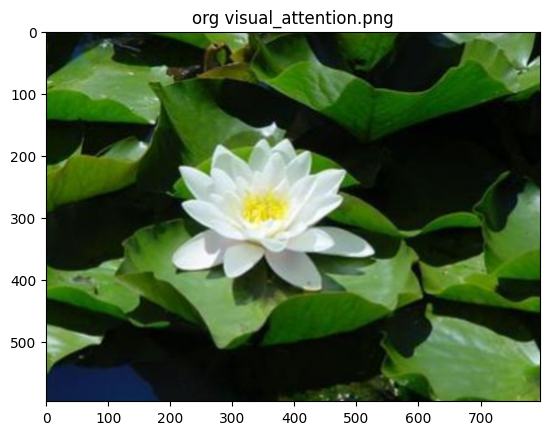

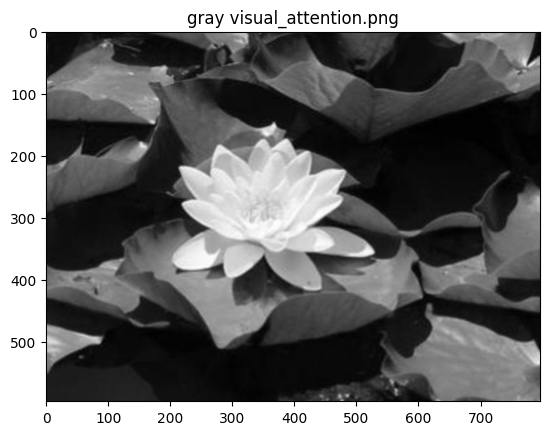

In [9]:
img = load_display_img(pth)

### c-s pyramids

#### c

In [10]:
centre_pyr = tuple(ski.transform.pyramid_gaussian(img, max_layer=4, sigma=9))

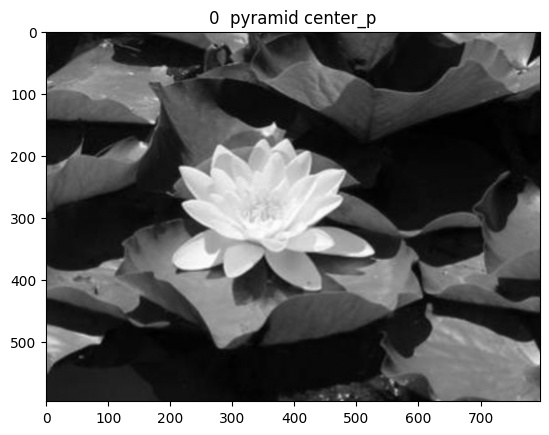

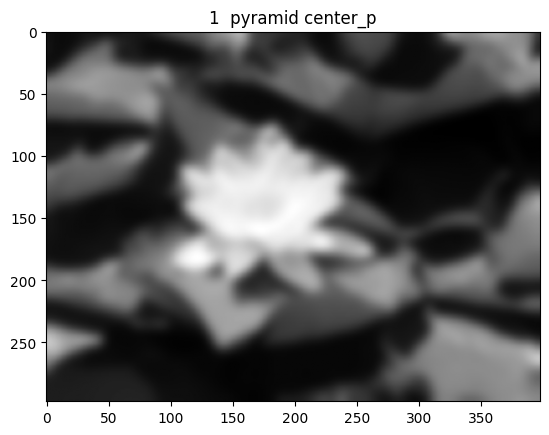

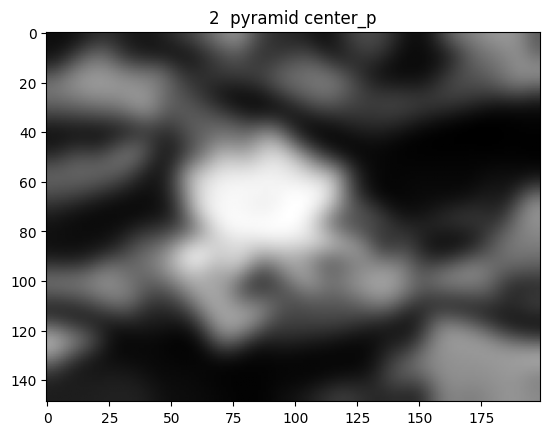

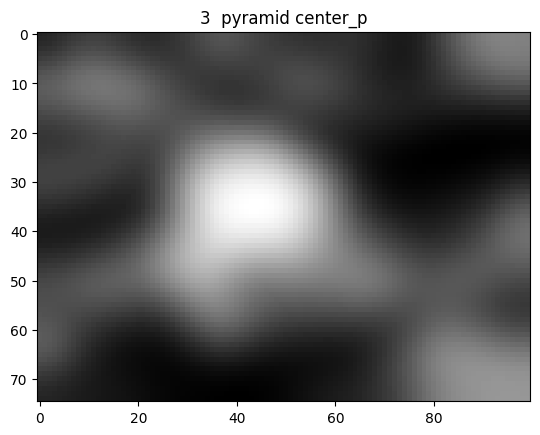

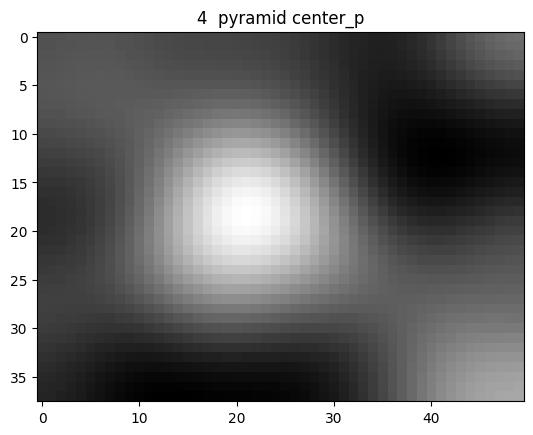

In [11]:
vis_pyramid(centre_pyr, 'center_p')

#### s

In [12]:
surround_pyr = tuple(ski.transform.pyramid_gaussian(img, max_layer=4, sigma=16))

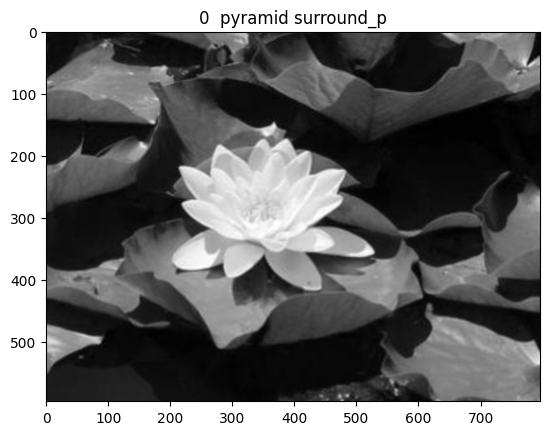

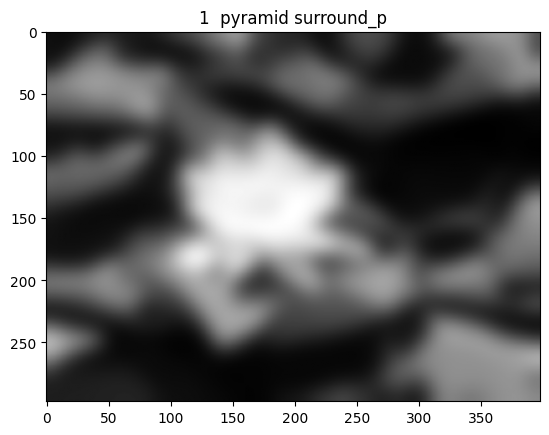

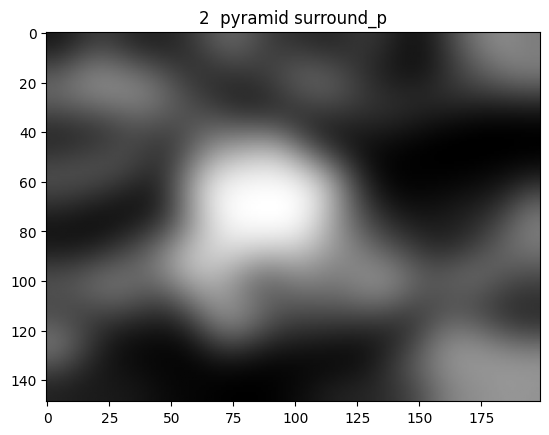

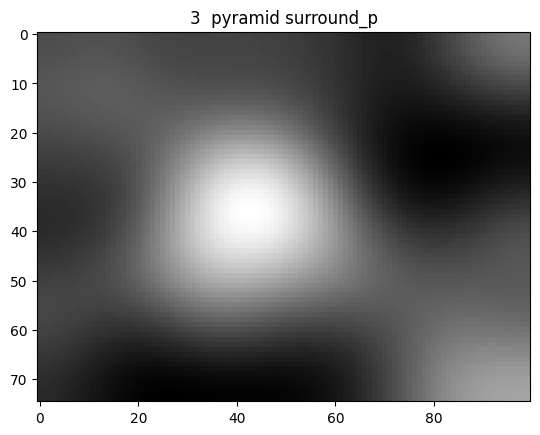

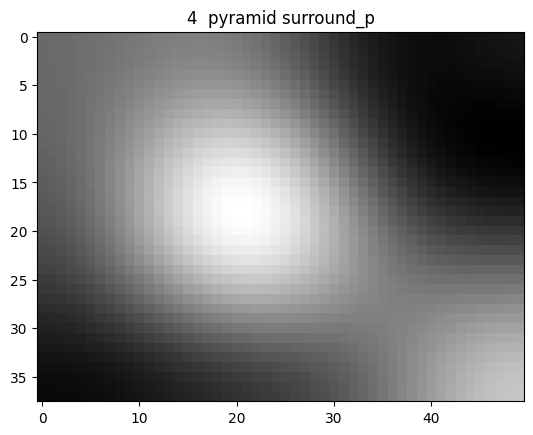

In [13]:
vis_pyramid(surround_pyr, 'surround_p')

### contrast pyramids

#### on-off

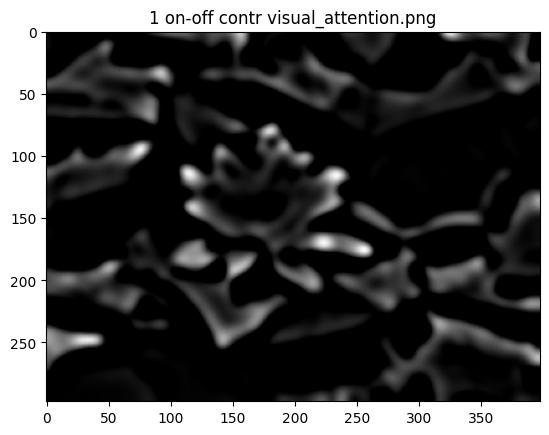

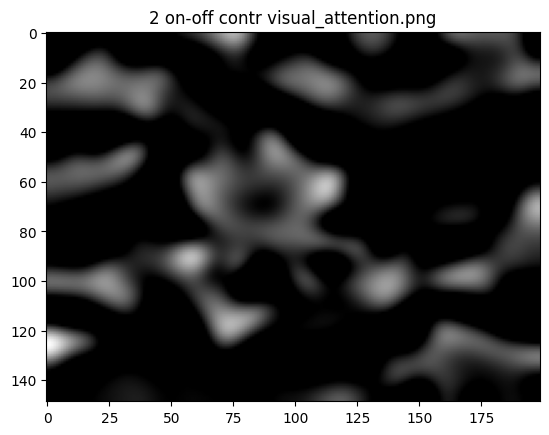

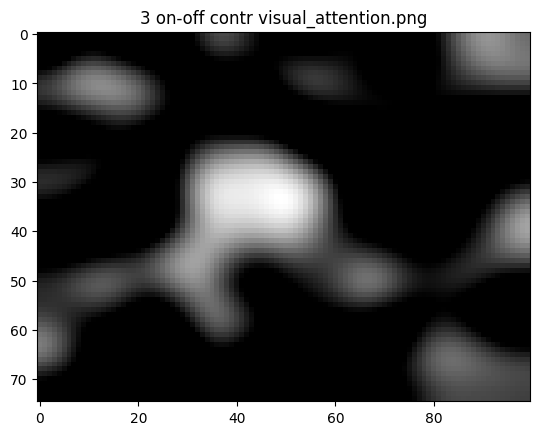

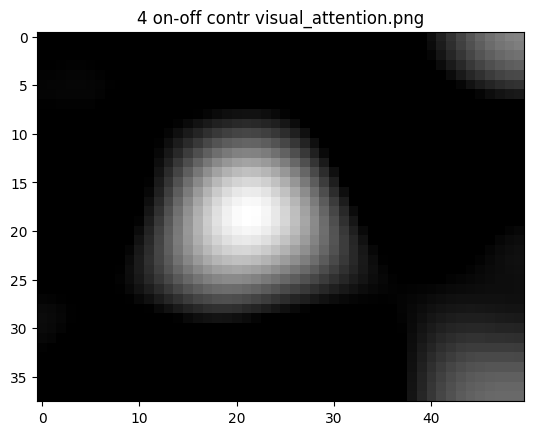

In [14]:
on_off_pyramid = calc_vis_contrast_pyramid(centre_pyr, surround_pyr, pth)

#### off-on

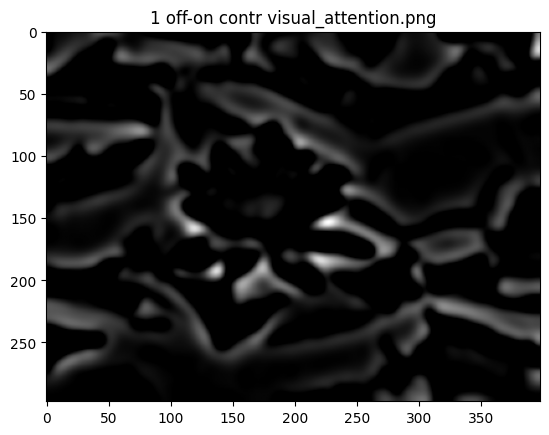

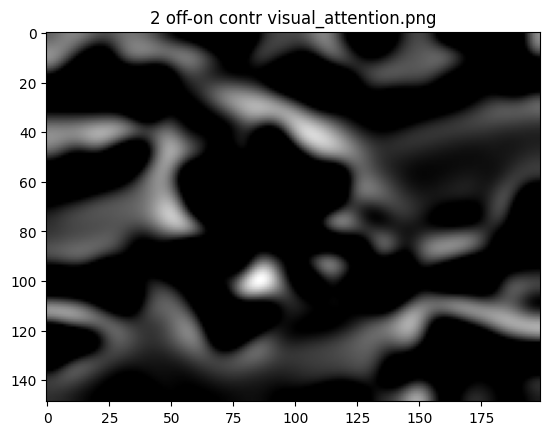

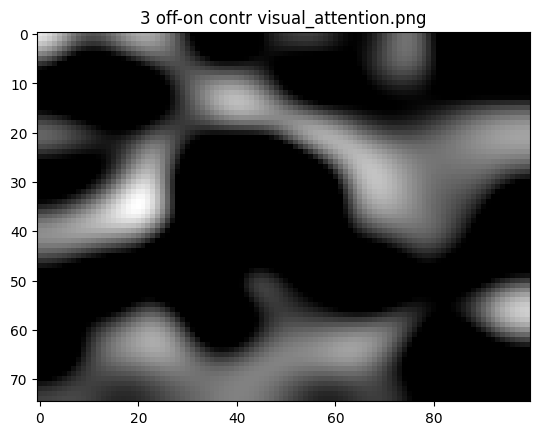

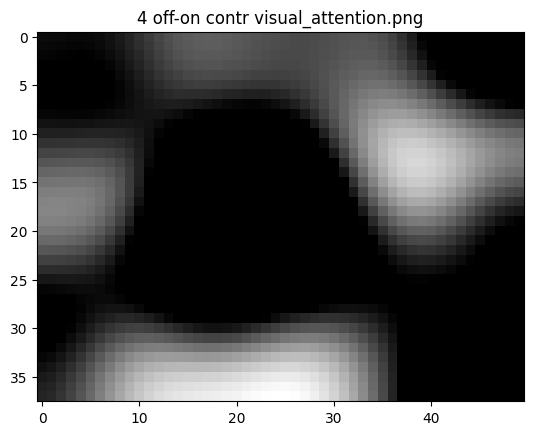

In [15]:
off_on_pyramid = calc_vis_contrast_pyramid(centre_pyr, surround_pyr, pth, is_on_off=False)

### feature maps

#### on-off

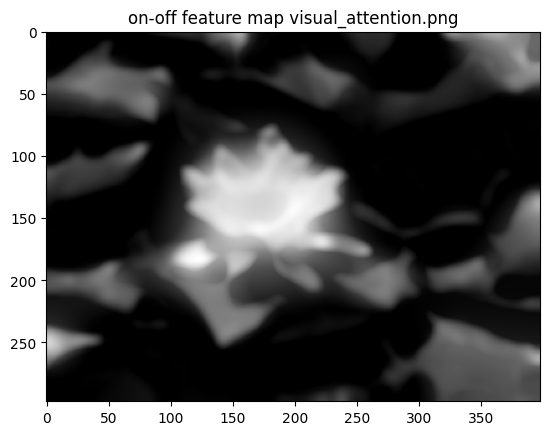

In [16]:
on_off_fm = calc_vis_feature_map(on_off_pyramid, pth, 'on-off')

#### off-on

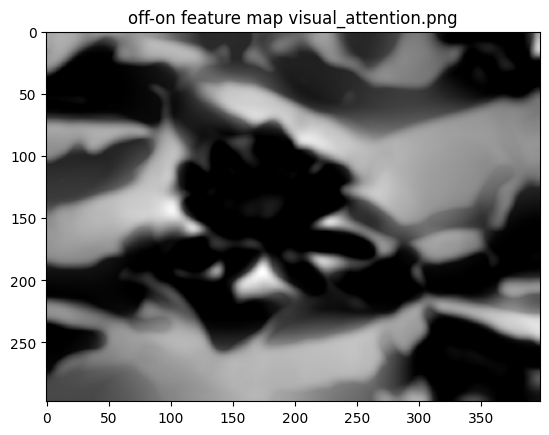

In [17]:
off_on_fm = calc_vis_feature_map(off_on_pyramid, pth, 'off-on')

### conspicuity map

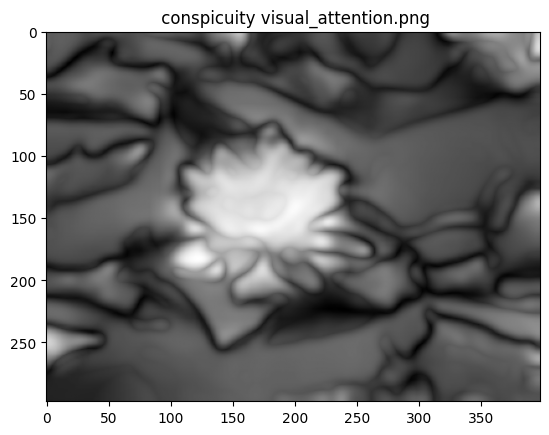

In [18]:
conspicuity_map = calc_vis_conspicuity_map(on_off_fm, off_on_fm, pth)

advantage over the integral image method: 